# 10 · Unsupervised Learning: Clustering & Dimensionality Reduction

[← Course home](../README.md)

So far every dataset came with a target column `y`. In **unsupervised learning** there is no `y`:
we look for *structure* in `X` alone — groups of similar rows (**clustering**) or a small number of
directions that capture most of the variation (**dimensionality reduction**).

**What you will learn**

- k-means **from scratch**: Lloyd's algorithm and k-means++ initialisation, verified against `sklearn.cluster.KMeans`
- How to choose $k$: the elbow (inertia) curve, silhouette scores and silhouette plots
- When k-means fails (non-spherical clusters, unequal variances) and what DBSCAN / Gaussian mixtures do instead
- Hierarchical clustering: linkage methods, dendrograms, cutting the tree, `AgglomerativeClustering`
- PCA **from scratch** via the SVD, verified against `sklearn.decomposition.PCA` (including the sign ambiguity)
- Scree plots, 2-D projections, image reconstruction and why scaling matters for PCA
- t-SNE: the perplexity knob, and what you must *not* read into a t-SNE plot
- Using the Adjusted Rand Index (ARI) as a sanity check when labels happen to exist

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_digits, make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from mlaz import PALETTE, load_penguins, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
T0 = time.time()

## 1 · k-means from scratch

k-means looks for $k$ centroids $\mu_1,\dots,\mu_k$ that minimise the **inertia** (within-cluster sum of squares):

$$J(\mu, c) = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert^2 .$$

**Lloyd's algorithm** alternates two steps, each of which can only decrease $J$:

1. **Assignment:** $c_i \leftarrow \arg\min_j \lVert x_i-\mu_j\rVert^2$ (nearest centroid).
2. **Update:** $\mu_j \leftarrow \frac{1}{|C_j|}\sum_{i\in C_j} x_i$ (mean of the assigned points).

Because $J$ decreases monotonically and there are finitely many partitions, the algorithm always
converges — but only to a **local** minimum. Hence the importance of initialisation.

**k-means++** (Arthur & Vassilvitskii, 2007) picks the first centroid uniformly at random, then each next
centroid with probability proportional to $D(x)^2$, the squared distance to the nearest centroid chosen so far.
Spread-out seeds → faster convergence and a provably good expected solution ($O(\log k)$-competitive).

In [2]:
def kmeans_plusplus(X, k, rng):
    """k-means++ seeding: sample each new centre with prob. ∝ squared distance to nearest centre."""
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    for _ in range(1, k):
        d2 = np.min(((X[:, None, :] - np.array(centers)[None, :, :]) ** 2).sum(axis=2), axis=1)
        centers.append(X[rng.choice(n, p=d2 / d2.sum())])
    return np.array(centers)


def lloyd(X, init_centers, max_iter=300, tol=1e-8):
    """Lloyd's algorithm. Returns centres, labels, inertia, n_iter and the centre history."""
    C = init_centers.astype(float).copy()
    history = [C.copy()]
    for it in range(1, max_iter + 1):
        d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)   # (n, k) squared distances
        labels = d2.argmin(axis=1)                                 # assignment step
        C_new = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else C[j]
                          for j in range(len(C))])                 # update step (keep empty clusters)
        history.append(C_new.copy())
        shift = ((C_new - C) ** 2).sum()
        C = C_new
        if shift < tol:
            break
    d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    labels = d2.argmin(axis=1)
    inertia = d2[np.arange(len(X)), labels].sum()
    return C, labels, inertia, it, history


def kmeans_scratch(X, k, n_init=10, init="k-means++", seed=RANDOM_STATE):
    """Run Lloyd n_init times and keep the lowest-inertia solution (like sklearn)."""
    r = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        C0 = kmeans_plusplus(X, k, r) if init == "k-means++" else X[r.choice(len(X), k, replace=False)]
        res = lloyd(X, C0)
        if best is None or res[2] < best[2]:
            best = res
    return best

A toy dataset with four blobs so that we can *see* the algorithm work.

In [3]:
X_blobs, y_blobs = make_blobs(n_samples=600, centers=4, cluster_std=[1.0, 1.3, 0.8, 1.1],
                              random_state=RANDOM_STATE)
print(X_blobs.shape)

(600, 2)


### Watching Lloyd's algorithm iterate

To make the iterations visible we start from a deliberately poor *random* initialisation
(four points drawn uniformly from the data) instead of k-means++.

converged after 12 iterations, inertia = 1313.3


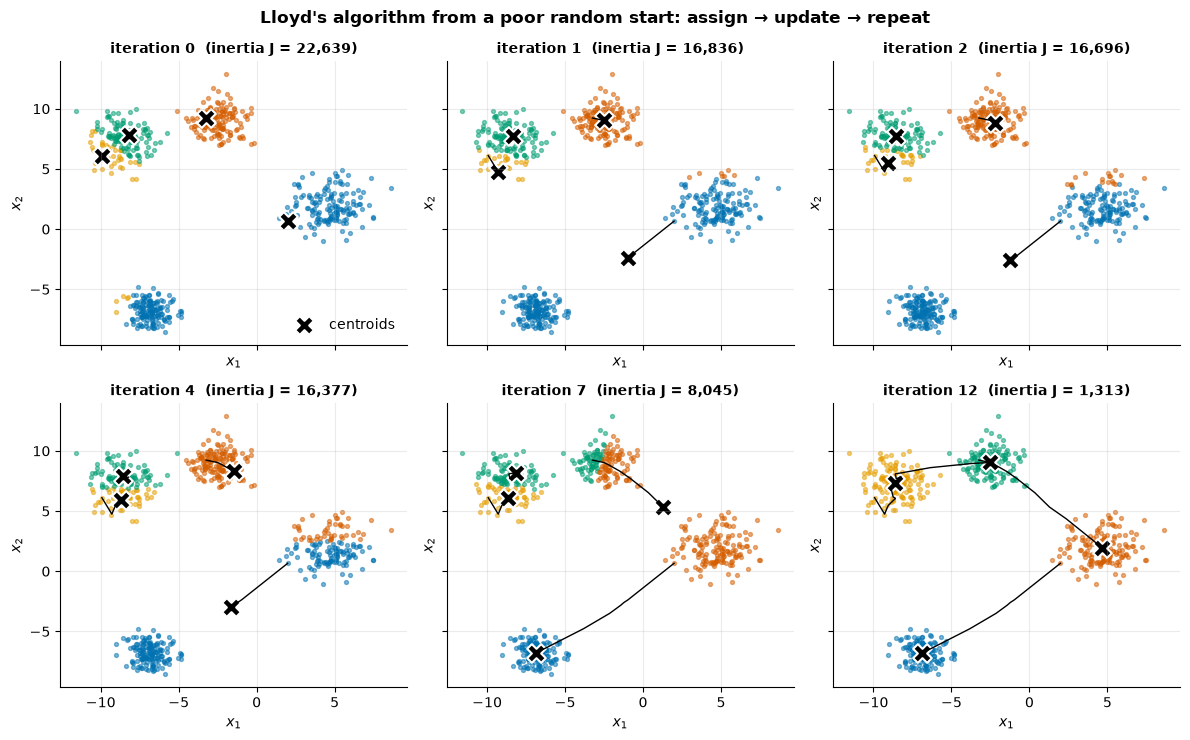

In [4]:
r_bad = np.random.default_rng(4)
C0_bad = X_blobs[r_bad.choice(len(X_blobs), 4, replace=False)]
C_fin, lab_fin, inertia_fin, n_it, hist = lloyd(X_blobs, C0_bad)
print(f"converged after {n_it} iterations, inertia = {inertia_fin:.1f}")

show = [0, 1, 2, 4, 7, len(hist) - 1]
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), show):
    C = hist[t]
    lab = ((X_blobs[:, None, :] - C[None]) ** 2).sum(axis=2).argmin(axis=1)
    J = ((X_blobs - C[lab]) ** 2).sum()
    for j in range(4):
        ax.scatter(*X_blobs[lab == j].T, s=8, alpha=0.5, color=PALETTE[j])
    # trail of each centroid up to iteration t
    trail = np.array(hist[: t + 1])
    for j in range(4):
        ax.plot(trail[:, j, 0], trail[:, j, 1], "-", color="k", lw=1)
    ax.scatter(*C.T, marker="X", s=180, color="k", edgecolor="white", linewidth=1.5, label="centroids")
    ax.set_title(f"iteration {t}  (inertia J = {J:,.0f})", fontsize=10)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
axes[0, 0].legend(loc="lower right")
fig.suptitle("Lloyd's algorithm from a poor random start: assign → update → repeat", fontweight="bold")
fig.tight_layout()
savefig("kmeans_iterations")
plt.show()

### Verifying against scikit-learn

Two checks:
1. **Same start → same answer.** Given identical initial centres, our Lloyd iterations must land on the
   same centres as `KMeans(init=C0, n_init=1)` (sklearn uses the same algorithm with `algorithm="lloyd"`).
2. **Same objective.** With k-means++ and 10 restarts both implementations should find the same partition
   (ARI = 1) and the same inertia, even though the random numbers differ.

In [5]:
km_same = KMeans(n_clusters=4, init=C0_bad, n_init=1, algorithm="lloyd", tol=1e-8).fit(X_blobs)
print("same init  -> centres allclose:", np.allclose(np.sort(C_fin, axis=0), np.sort(km_same.cluster_centers_, axis=0)),
      "| inertia ours %.3f vs sklearn %.3f" % (inertia_fin, km_same.inertia_))

C_s, lab_s, inertia_s, _, _ = kmeans_scratch(X_blobs, 4, n_init=10)
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
pd.DataFrame({
    "inertia": [inertia_s, km.inertia_],
    "ARI vs other impl.": [adjusted_rand_score(km.labels_, lab_s)] * 2,
    "ARI vs true blobs": [adjusted_rand_score(y_blobs, lab_s), adjusted_rand_score(y_blobs, km.labels_)],
}, index=["from scratch", "sklearn KMeans"]).round(4)

same init  -> centres allclose: True | inertia ours 1313.330 vs sklearn 1313.330


,inertia,ARI vs other impl.,ARI vs true blobs
from scratch,1313.33,1.0,0.9955
sklearn KMeans,1313.33,1.0,0.9955


> **Note** Cluster *numbers* are arbitrary (label switching): cluster 0 in one run may be cluster 2 in another.
> That is why we compare partitions with the **Adjusted Rand Index**, which is invariant to relabelling
> (1 = identical partitions, ≈0 = chance agreement).

## 2 · Choosing $k$

Inertia always decreases as $k$ grows (with $k=n$ it is zero), so we cannot simply minimise it.

- **Elbow method:** plot inertia vs $k$ and look for the "knee" where extra clusters stop paying off.
- **Silhouette score:** for each point, let $a(i)$ be its mean distance to points in its own cluster and
  $b(i)$ the mean distance to points in the *nearest other* cluster. Then

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} \in [-1, 1].$$

$s\approx 1$: well inside its cluster; $s \approx 0$: on a border; $s<0$: probably in the wrong cluster.
The mean silhouette over all points is a single score we can maximise over $k$.

 k  inertia  silhouette
 2  18789.0       0.592
 3   4315.0       0.751
 4   1313.0       0.774
 5   1151.0       0.659
 6   1016.0       0.565
 7    908.0       0.576
 8    811.0       0.481
 9    737.0       0.479
10    666.0       0.344
best k by silhouette: 4


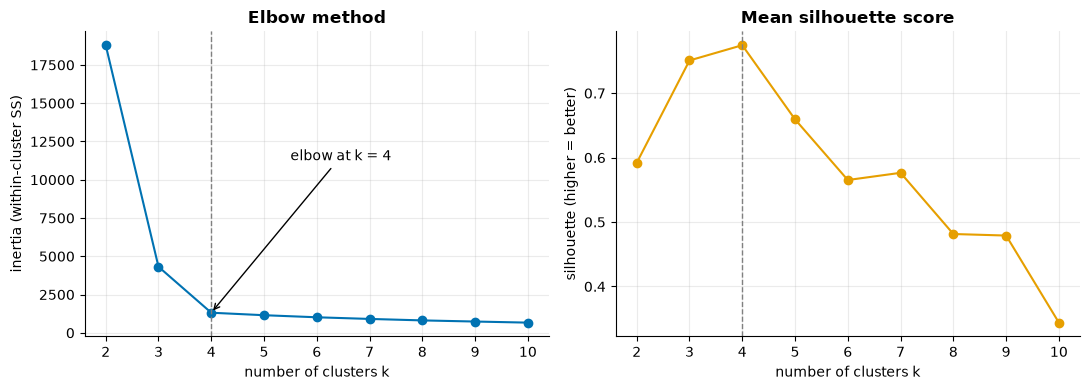

In [6]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
    inertias.append(m.inertia_)
    sils.append(silhouette_score(X_blobs, m.labels_))
best_k = list(ks)[int(np.argmax(sils))]
print(pd.DataFrame({"k": list(ks), "inertia": np.round(inertias, 0), "silhouette": np.round(sils, 3)}).to_string(index=False))
print("best k by silhouette:", best_k)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].axvline(4, color="grey", ls="--", lw=1)
axes[0].annotate("elbow at k = 4", (4, inertias[2]), xytext=(5.5, inertias[0] * 0.6),
                 arrowprops=dict(arrowstyle="->"))
axes[0].set(title="Elbow method", xlabel="number of clusters k", ylabel="inertia (within-cluster SS)")
axes[1].plot(list(ks), sils, "o-", color=PALETTE[1])
axes[1].axvline(best_k, color="grey", ls="--", lw=1)
axes[1].set(title="Mean silhouette score", xlabel="number of clusters k", ylabel="silhouette (higher = better)")
fig.tight_layout()
savefig("choosing_k")
plt.show()

### Silhouette plots

A single average can hide problems. A **silhouette plot** shows every point's $s(i)$, sorted within each
cluster. Good clusterings have "knives" of similar thickness that mostly exceed the average line;
thin clusters or many negative values signal a poor $k$.

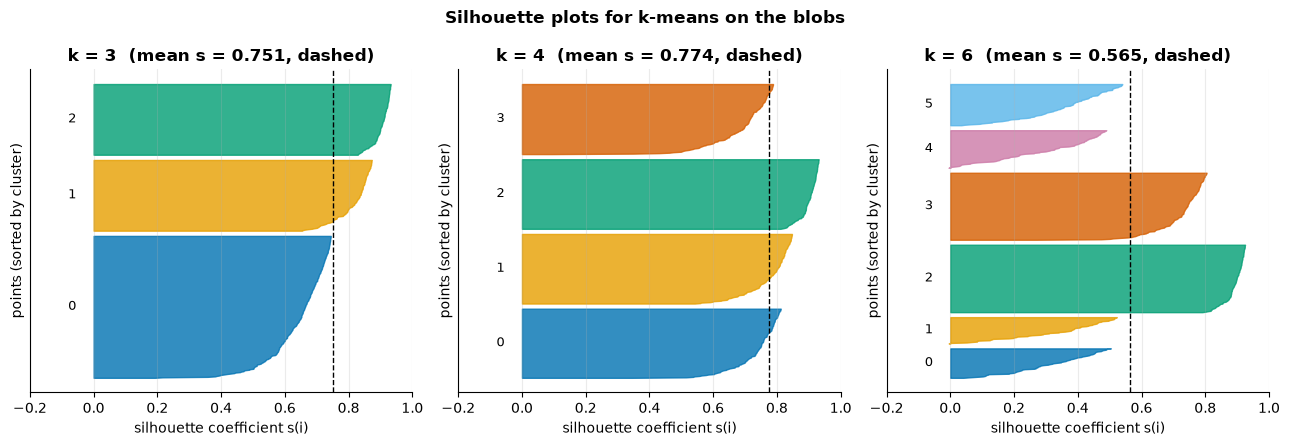

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, k in zip(axes, [3, 4, 6]):
    m = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
    s = silhouette_samples(X_blobs, m.labels_)
    y_lo = 10
    for j in range(k):
        sj = np.sort(s[m.labels_ == j])
        ax.fill_betweenx(np.arange(y_lo, y_lo + len(sj)), 0, sj, color=PALETTE[j % len(PALETTE)], alpha=0.8)
        ax.text(-0.08, y_lo + len(sj) / 2, str(j), va="center", fontsize=9)
        y_lo += len(sj) + 10
    ax.axvline(s.mean(), color="k", ls="--", lw=1)
    ax.set(title=f"k = {k}  (mean s = {s.mean():.3f}, dashed)", xlabel="silhouette coefficient s(i)", ylabel="points (sorted by cluster)",
           xlim=(-0.2, 1), yticks=[])
fig.suptitle("Silhouette plots for k-means on the blobs", fontweight="bold")
fig.tight_layout()
savefig("silhouette_plots")
plt.show()

## 3 · When k-means fails

k-means implicitly assumes clusters are **convex, isotropic (round) and of similar size/spread** — because
every point simply goes to its nearest centroid, the decision boundaries are straight lines halfway
between centroids (a Voronoi diagram). Alternatives:

| Method | Idea | Needs $k$? | Cluster shapes |
|---|---|---|---|
| **k-means** | nearest centroid | yes | convex, similar spread |
| **Gaussian mixture (GMM)** | soft assignment to $k$ Gaussians, each with its own covariance, fitted by EM | yes | ellipses of any size/orientation |
| **DBSCAN** | points with ≥ `min_samples` neighbours within `eps` are *core*; clusters = connected dense regions | no | arbitrary; labels outliers as noise (−1) |

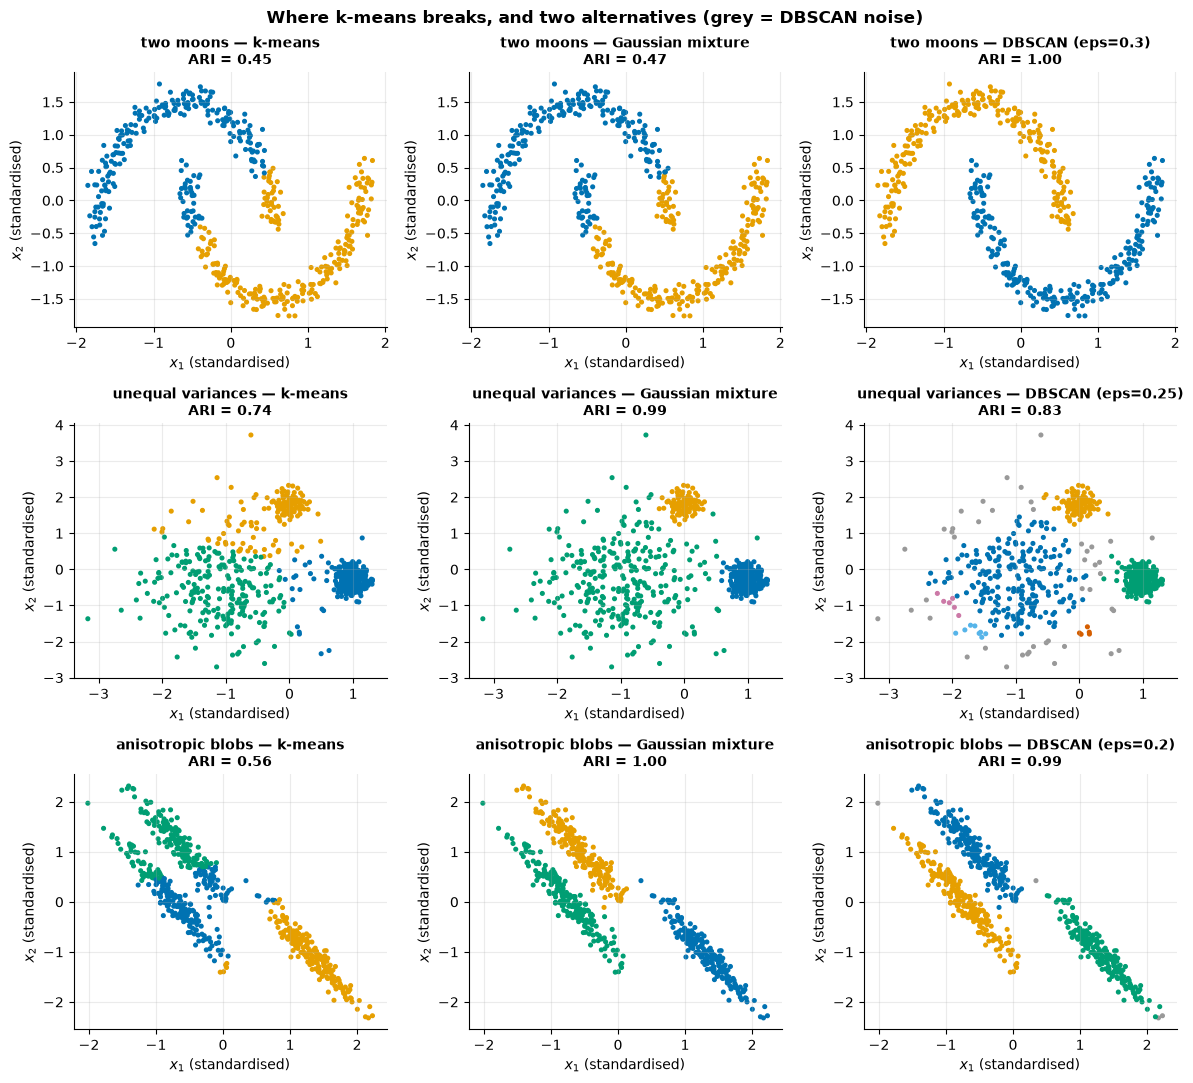

method,DBSCAN,Gaussian mixture,k-means
dataset,,,
anisotropic blobs,0.990,1.000,0.564
two moons,1.000,0.472,0.450
unequal variances,0.834,0.993,0.736


In [8]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.06, random_state=RANDOM_STATE)
X_var, y_var = make_blobs(n_samples=[300, 300, 100], centers=[[0, 0], [7, 0], [3.5, 5]],
                          cluster_std=[2.5, 0.5, 0.5], random_state=RANDOM_STATE)
X_aniso, y_aniso = make_blobs(n_samples=600, centers=3, random_state=170)
X_aniso = X_aniso @ np.array([[0.6, -0.64], [-0.41, 0.85]])

datasets = {
    "two moons": (X_moons, y_moons, 2, 0.3),
    "unequal variances": (X_var, y_var, 3, 0.25),
    "anisotropic blobs": (X_aniso, y_aniso, 3, 0.2),
}
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
ari_rows = []
for r, (name, (X, y, k, eps)) in enumerate(datasets.items()):
    Xs = StandardScaler().fit_transform(X)
    models = {
        "k-means": KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE),
        "Gaussian mixture": GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE),
        f"DBSCAN (eps={eps})": DBSCAN(eps=eps, min_samples=5),
    }
    for c, (mname, model) in enumerate(models.items()):
        lab = model.fit_predict(Xs)
        ari = adjusted_rand_score(y, lab)
        ari_rows.append({"dataset": name, "method": mname.split(" (")[0], "ARI": ari})
        ax = axes[r, c]
        colors = np.array([PALETTE[i % len(PALETTE)] for i in range(max(lab.max() + 1, 1))] + ["#999999"])
        ax.scatter(*Xs.T, s=7, c=colors[np.where(lab < 0, -1, lab)])
        ax.set_title(f"{name} — {mname}\nARI = {ari:.2f}", fontsize=10)
        ax.set_xlabel("$x_1$ (standardised)"); ax.set_ylabel("$x_2$ (standardised)")
fig.suptitle("Where k-means breaks, and two alternatives (grey = DBSCAN noise)", fontweight="bold")
fig.tight_layout()
savefig("kmeans_failure_modes")
plt.show()
pd.DataFrame(ari_rows).pivot(index="dataset", columns="method", values="ARI").round(3)

Reading the grid:

- **Moons:** only the density-based DBSCAN recovers the two crescents; k-means and the GMM cut them with a line.
- **Unequal variances:** k-means puts the boundary halfway between centroids, so it steals points from the
  wide cluster; the GMM models a different spread per component.
- **Anisotropic:** stretched clusters break the "round" assumption — the GMM's full covariances fit them.

DBSCAN is not a free lunch: `eps` is sensitive to scale (hence `StandardScaler`) and it struggles when
clusters have *different* densities.

## 4 · Hierarchical (agglomerative) clustering

Start with every point as its own cluster and repeatedly **merge the two closest clusters** until one remains.
"Closest" depends on the **linkage**, i.e. how the distance between two *sets* $A,B$ is defined:

| Linkage | $d(A,B)$ | Behaviour |
|---|---|---|
| single | $\min_{a\in A,b\in B}\lVert a-b\rVert$ | follows chains; can find elongated shapes but "chaining" merges distinct groups through bridges |
| complete | $\max_{a,b}\lVert a-b\rVert$ | compact clusters of similar diameter |
| average | mean of all pairwise distances | compromise |
| ward | increase in total within-cluster SS when merging | like k-means: compact, similar size; the usual default |

The full merge history is a tree — the **dendrogram** — and cutting it at a height gives a flat clustering
for any number of clusters without refitting.

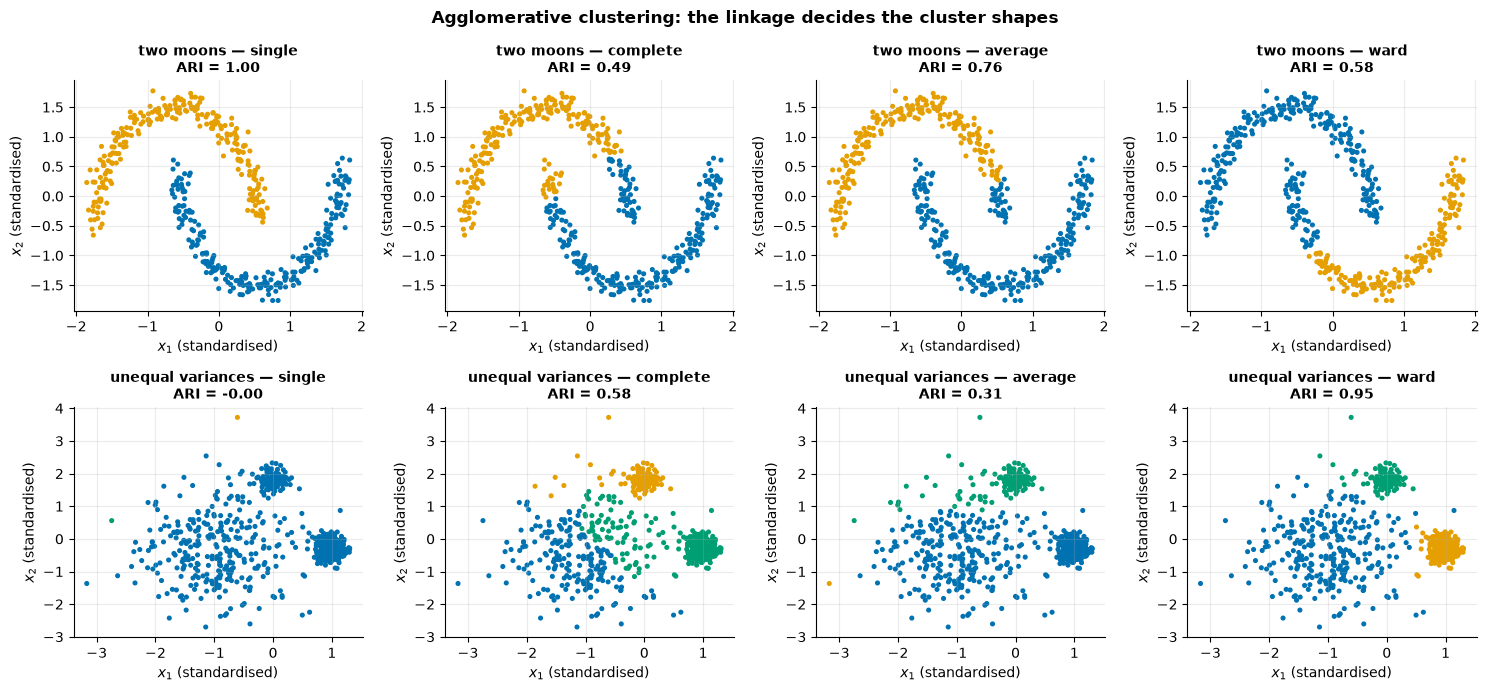

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for r, (name, (X, y, k, _)) in enumerate(list(datasets.items())[:2]):
    Xs = StandardScaler().fit_transform(X)
    for c, link in enumerate(["single", "complete", "average", "ward"]):
        lab = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(Xs)
        ax = axes[r, c]
        ax.scatter(*Xs.T, s=7, c=np.array(PALETTE)[lab])
        ax.set_title(f"{name} — {link}\nARI = {adjusted_rand_score(y, lab):.2f}", fontsize=10)
        ax.set_xlabel("$x_1$ (standardised)"); ax.set_ylabel("$x_2$ (standardised)")
fig.suptitle("Agglomerative clustering: the linkage decides the cluster shapes", fontweight="bold")
fig.tight_layout()
savefig("linkage_comparison")
plt.show()

Single linkage nails the moons (chaining is exactly what connects a crescent) but on the unequal-variance
data it chains almost everything into one cluster and leaves tiny outlier clusters. Ward is the robust default
for "blob-like" data.

### Dendrogram on the Palmer penguins

Let us cluster the four numeric penguin measurements (standardised — see §6 for why) with Ward linkage,
using `scipy.cluster.hierarchy`, and pretend we do not know the species.

(342, 4) {'Adelie': 151, 'Gentoo': 123, 'Chinstrap': 68}
last three merge heights: [12.35 18.59 40.06] -> cut at 15.47


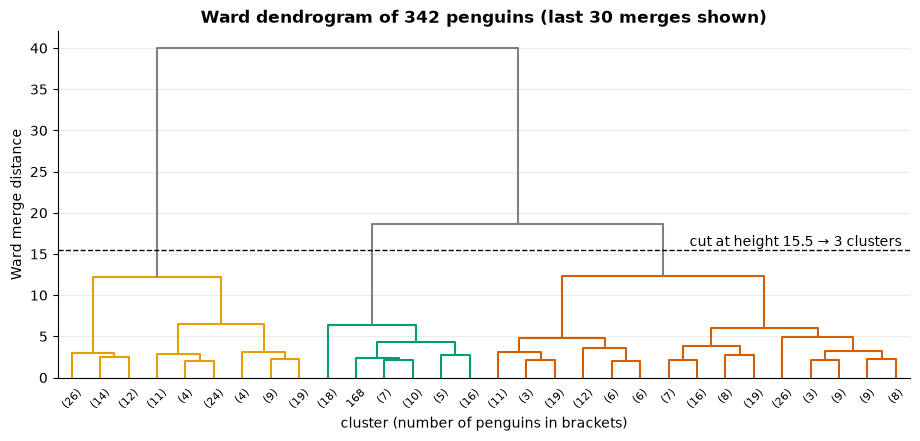

In [10]:
peng = load_penguins().dropna(subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"])
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_peng = peng[num_cols].to_numpy()
y_peng = peng["species"].to_numpy()
X_peng_s = StandardScaler().fit_transform(X_peng)
print(X_peng.shape, pd.Series(y_peng).value_counts().to_dict())

Z = linkage(X_peng_s, method="ward")    # (n-1) x 4 merge table: [idx_a, idx_b, distance, size]
# cut halfway between the merge that leaves 3 clusters and the one that leaves 2
cut_height = (Z[-3, 2] + Z[-2, 2]) / 2
print("last three merge heights:", Z[-3:, 2].round(2), "-> cut at", round(cut_height, 2))
fig, ax = plt.subplots(figsize=(11, 4.5))
dendrogram(Z, truncate_mode="lastp", p=30, color_threshold=cut_height, above_threshold_color="grey",
           leaf_font_size=8, ax=ax)
ax.axhline(cut_height, color="k", ls="--", lw=1)
ax.text(ax.get_xlim()[1] * 0.99, cut_height + 0.5, f"cut at height {cut_height:.1f} → 3 clusters", ha="right")
ax.set(title="Ward dendrogram of 342 penguins (last 30 merges shown)",
       xlabel="cluster (number of penguins in brackets)", ylabel="Ward merge distance")
ax.grid(axis="x", visible=False)
savefig("dendrogram_penguins")
plt.show()

Long vertical stems mean "these two groups were far apart when merged" — a natural place to cut.
`fcluster` cuts the tree; `AgglomerativeClustering` gives the same partition directly.

In [11]:
lab_cut = fcluster(Z, t=cut_height, criterion="distance")
lab_agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_peng_s)
print("clusters from the cut:", np.unique(lab_cut))
print("ARI scipy cut vs sklearn AgglomerativeClustering:", round(adjusted_rand_score(lab_cut, lab_agg), 4))
print("ARI clusters vs true species:", round(adjusted_rand_score(y_peng, lab_agg), 3))
pd.crosstab(pd.Series(y_peng, name="species"), pd.Series(lab_agg, name="cluster"))

clusters from the cut: [1 2 3]
ARI scipy cut vs sklearn AgglomerativeClustering: 1.0
ARI clusters vs true species: 0.916


cluster,0,1,2
species,,,
Adelie,151,0,0
Chinstrap,11,0,57
Gentoo,0,123,0


## 5 · PCA from scratch via the SVD

**Principal Component Analysis** finds orthonormal directions $w_1, w_2, \dots$ of maximal variance.
With the centred data matrix $X_c = X - \bar x$ (shape $n\times p$), take its thin SVD

$$X_c = U \Sigma V^\top .$$

- The rows of $V^\top$ are the **principal axes** (loadings) $w_j$.
- The variance along axis $j$ is $\lambda_j = \sigma_j^2/(n-1)$ (the eigenvalues of the covariance matrix
  $\frac{1}{n-1}X_c^\top X_c = V \frac{\Sigma^2}{n-1} V^\top$).
- The **explained variance ratio** is $\lambda_j / \sum_l \lambda_l$.
- The **scores** (projections) are $Z = X_c V_k = U_k\Sigma_k$, and the rank-$k$ **reconstruction** is
  $\hat X = Z V_k^\top + \bar x$ — the best rank-$k$ approximation in squared error (Eckart–Young).

Using the SVD rather than forming $X_c^\top X_c$ is numerically more stable.

In [12]:
class PCAScratch:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        var = S**2 / (X.shape[0] - 1)
        self.components_ = Vt[: self.n_components]
        self.explained_variance_ = var[: self.n_components]
        self.explained_variance_ratio_ = (var / var.sum())[: self.n_components]
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


digits = load_digits()
X_dig, y_dig = digits.data, digits.target
print("digits:", X_dig.shape, "(8x8 images, pixel intensities 0-16)")

pca_me = PCAScratch(10).fit(X_dig)
pca_sk = PCA(n_components=10, svd_solver="full").fit(X_dig)

digits: (1797, 64) (8x8 images, pixel intensities 0-16)


**Sign ambiguity.** If $w$ is a principal axis, so is $-w$ (flip the sign of a column of $U$ and the
matching row of $V^\top$ and the product is unchanged). sklearn applies a deterministic `svd_flip`
convention; ours is whatever LAPACK returns. So we align signs before comparing.

In [13]:
signs = np.sign((pca_me.components_ * pca_sk.components_).sum(axis=1))
print("signs that had to be flipped:", signs.astype(int))
checks = {
    "explained_variance_ratio_": np.allclose(pca_me.explained_variance_ratio_, pca_sk.explained_variance_ratio_),
    "explained_variance_": np.allclose(pca_me.explained_variance_, pca_sk.explained_variance_),
    "components_ (after sign fix)": np.allclose(pca_me.components_ * signs[:, None], pca_sk.components_),
    "transform (after sign fix)": np.allclose(pca_me.transform(X_dig) * signs, pca_sk.transform(X_dig)),
    "inverse_transform": np.allclose(pca_me.inverse_transform(pca_me.transform(X_dig)),
                                     pca_sk.inverse_transform(pca_sk.transform(X_dig))),
}
pd.Series(checks, name="matches sklearn")

signs that had to be flipped: [-1  1  1  1  1 -1 -1  1  1  1]


explained_variance_ratio_       True
explained_variance_             True
components_ (after sign fix)    True
transform (after sign fix)      True
inverse_transform               True
Name: matches sklearn, dtype: bool

### How many components? Scree and cumulative variance

PC1 explains 14.9%, PC2 13.6%; first 2 together 28.5%
components for 90% variance: 21, for 95%: 29 (out of 64)


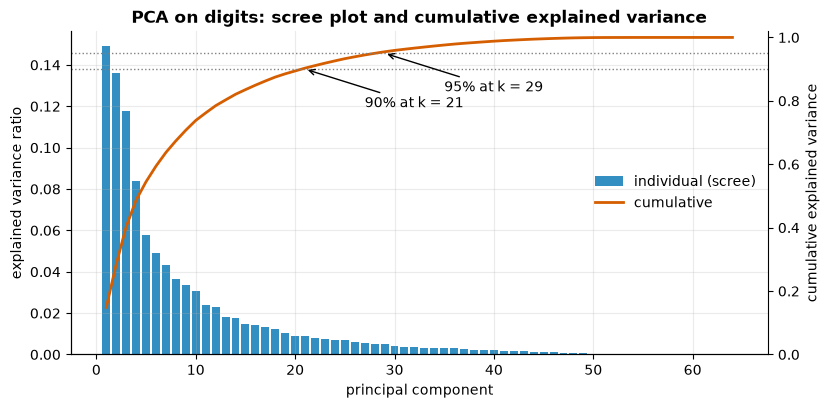

In [14]:
pca_full = PCAScratch(64).fit(X_dig)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
k90, k95 = int(np.searchsorted(cum, 0.90) + 1), int(np.searchsorted(cum, 0.95) + 1)
print(f"PC1 explains {evr[0]:.1%}, PC2 {evr[1]:.1%}; first 2 together {cum[1]:.1%}")
print(f"components for 90% variance: {k90}, for 95%: {k95} (out of 64)")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(np.arange(1, 65), evr, color=PALETTE[0], alpha=0.8, label="individual (scree)")
ax2 = ax.twinx()
ax2.plot(np.arange(1, 65), cum, color=PALETTE[3], lw=2, label="cumulative")
for thr, kk in [(0.90, k90), (0.95, k95)]:
    ax2.axhline(thr, color="grey", ls=":", lw=1)
    ax2.annotate(f"{thr:.0%} at k = {kk}", (kk, thr), xytext=(kk + 6, thr - 0.12), arrowprops=dict(arrowstyle="->"))
ax.set(title="PCA on digits: scree plot and cumulative explained variance",
       xlabel="principal component", ylabel="explained variance ratio")
ax2.set_ylabel("cumulative explained variance"); ax2.set_ylim(0, 1.02); ax2.grid(False)
ax2.spines["right"].set_visible(True)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right")
savefig("pca_scree")
plt.show()

### Reconstructing digits with $k$ components

Projecting onto $k$ components and mapping back shows what information PCA keeps. Few components give the
"average-ish" shape of a digit; around the 90 % variance mark most images are clearly readable.

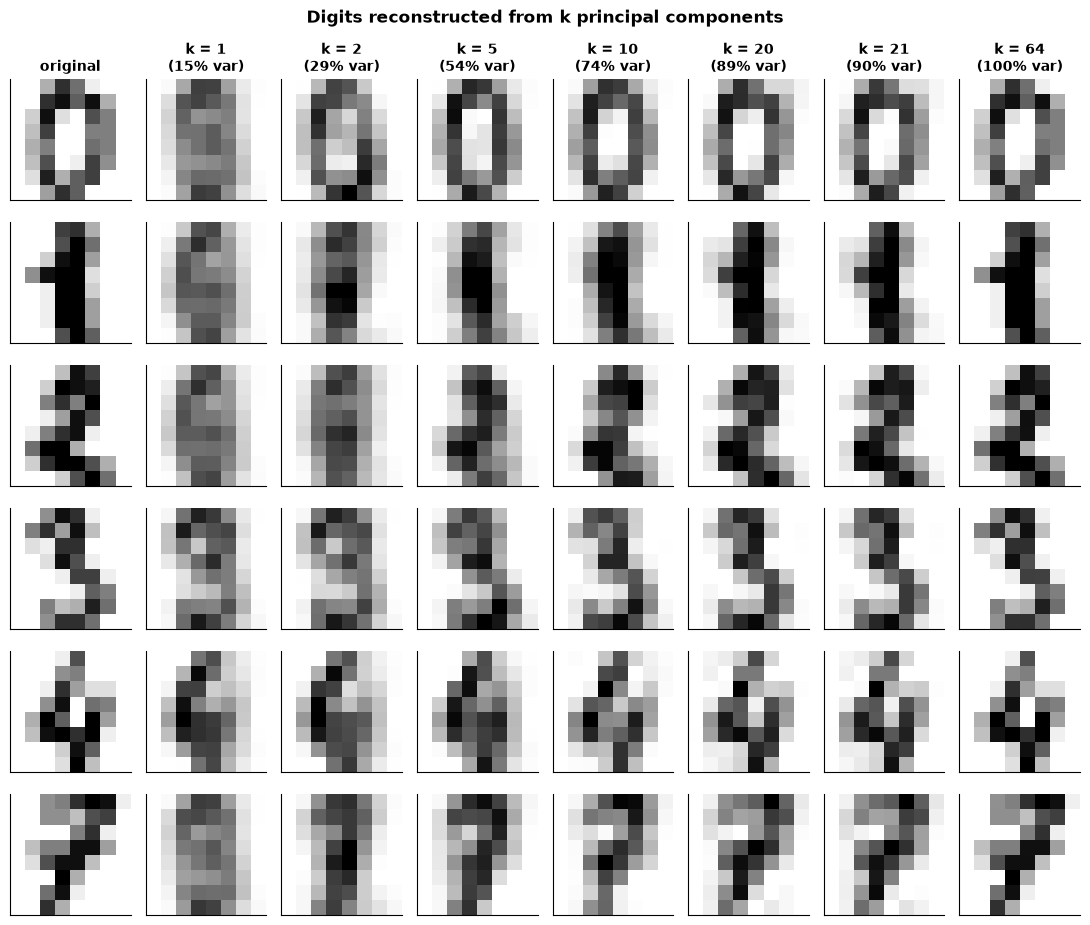

mean squared reconstruction error per pixel: {2: np.float64(13.421), 10: np.float64(4.914), 21: np.float64(1.817), 64: np.float64(0.0)}


In [15]:
ks_rec = [1, 2, 5, 10, 20, k90, 64]
idx_show = [0, 1, 2, 3, 4, 7]
fig, axes = plt.subplots(len(idx_show), len(ks_rec) + 1, figsize=(11, 9.5))
for c, k in enumerate(["original"] + ks_rec):
    if k == "original":
        imgs = X_dig[idx_show]; title = "original"
    else:
        p = PCAScratch(k).fit(X_dig)
        imgs = p.inverse_transform(p.transform(X_dig[idx_show]))
        title = f"k = {k}\n({np.cumsum(evr)[k-1]:.0%} var)"
    for r, img in enumerate(imgs):
        axes[r, c].imshow(img.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([]); axes[r, c].grid(False)
    axes[0, c].set_title(title, fontsize=10)
fig.suptitle("Digits reconstructed from k principal components", fontweight="bold")
fig.tight_layout()
savefig("pca_reconstruction")
plt.show()

rec_err = {k: np.mean((X_dig - PCAScratch(k).fit(X_dig).inverse_transform(PCAScratch(k).fit(X_dig).transform(X_dig))) ** 2)
           for k in [2, 10, k90, 64]}
print("mean squared reconstruction error per pixel:", {k: round(v, 3) for k, v in rec_err.items()})

## 6 · 2-D projections — and why scaling matters

PCA maximises *variance*, and variance depends on units. The penguin features are in millimetres (bill ≈ 40,
std ≈ 5) and grams (body mass ≈ 4200, std ≈ 800). Without scaling, PC1 is essentially "body mass" and the other
features are ignored. With `StandardScaler` every feature gets unit variance, so PCA now looks at the
**correlation** structure.

In [16]:
pca_raw = PCA(2).fit(X_peng)
pca_std = make_pipeline(StandardScaler(), PCA(2)).fit(X_peng)
load = pd.DataFrame({
    "PC1 raw": pca_raw.components_[0], "PC1 standardised": pca_std[-1].components_[0],
    "PC2 standardised": pca_std[-1].components_[1]}, index=num_cols).round(3)
print("explained variance ratio raw:", pca_raw.explained_variance_ratio_.round(4),
      "| standardised:", pca_std[-1].explained_variance_ratio_.round(3))
load

explained variance ratio raw: [9.999e-01 1.000e-04] | standardised: [0.688 0.193]


,PC1 raw,PC1 standardised,PC2 standardised
bill_length_mm,0.004,0.455,0.597
bill_depth_mm,-0.001,-0.400,0.798
flipper_length_mm,0.015,0.576,0.002
body_mass_g,1.000,0.548,0.084


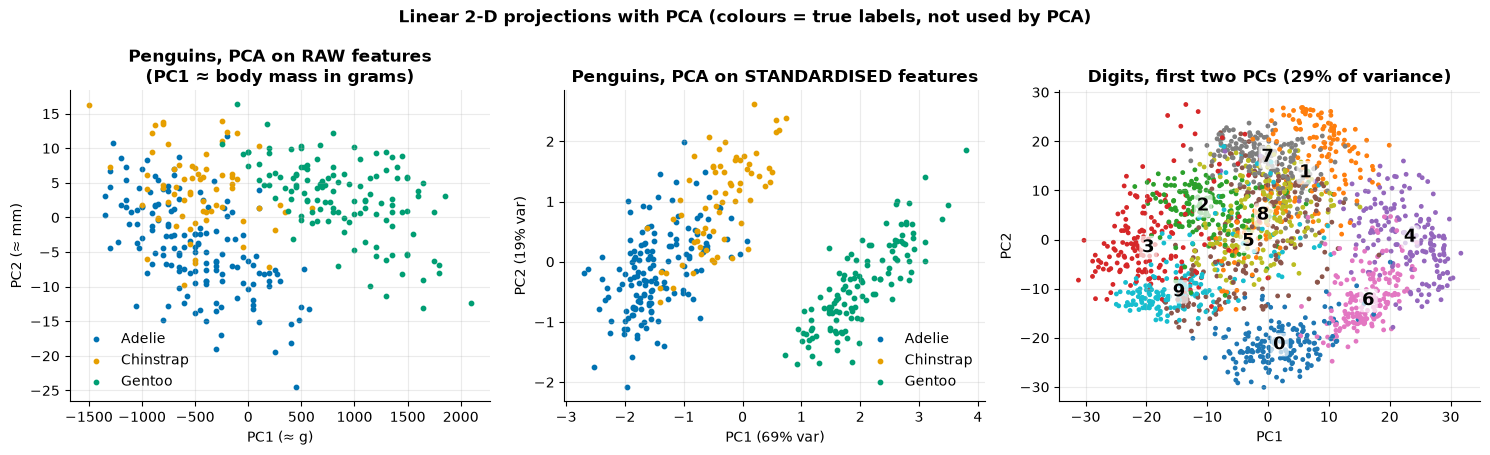

In [17]:
Z_raw, Z_std = pca_raw.transform(X_peng), pca_std.transform(X_peng)
Z_dig = PCA(2).fit_transform(X_dig)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for j, sp in enumerate(np.unique(y_peng)):
    axes[0].scatter(*Z_raw[y_peng == sp].T, s=10, color=PALETTE[j], label=sp)
    axes[1].scatter(*Z_std[y_peng == sp].T, s=10, color=PALETTE[j], label=sp)
axes[0].set(title="Penguins, PCA on RAW features\n(PC1 ≈ body mass in grams)", xlabel="PC1 (≈ g)", ylabel="PC2 (≈ mm)")
axes[1].set(title="Penguins, PCA on STANDARDISED features",
            xlabel=f"PC1 ({pca_std[-1].explained_variance_ratio_[0]:.0%} var)",
            ylabel=f"PC2 ({pca_std[-1].explained_variance_ratio_[1]:.0%} var)")
axes[0].legend(); axes[1].legend()
sc = axes[2].scatter(*Z_dig.T, c=y_dig, cmap="tab10", s=6)
for d in range(10):
    axes[2].text(*np.median(Z_dig[y_dig == d], axis=0), str(d), fontsize=13, weight="bold",
                 ha="center", va="center", bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, lw=0))
axes[2].set(title=f"Digits, first two PCs ({cum[1]:.0%} of variance)", xlabel="PC1", ylabel="PC2")
fig.suptitle("Linear 2-D projections with PCA (colours = true labels, not used by PCA)", fontweight="bold")
fig.tight_layout()
savefig("pca_projections")
plt.show()

The standardised penguin projection separates Gentoo cleanly; Adelie and Chinstrap overlap more.
The digits projection keeps only about 28 % of the variance, so many digits overlap — a linear 2-D view of a
64-D dataset is limited. Enter t-SNE.

## 7 · t-SNE: a non-linear map for visualisation

**t-SNE** (van der Maaten & Hinton, 2008) converts distances into neighbour probabilities. In the original
space, $p_{j|i} \propto \exp(-\lVert x_i-x_j\rVert^2 / 2\sigma_i^2)$, where each $\sigma_i$ is chosen so that
the distribution has a given **perplexity** (≈ effective number of neighbours). In 2-D it uses a heavy-tailed
Student-t kernel $q_{ij}\propto (1+\lVert y_i-y_j\rVert^2)^{-1}$ and moves the points $y_i$ to minimise

$$\mathrm{KL}(P\,\Vert\,Q) = \sum_{i\neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}} .$$

It is excellent at preserving **local neighbourhoods**, and deliberately *not* global geometry.

In [18]:
Z_tsne = {}
for perp in [5, 30, 100]:
    t0 = time.time()
    Z_tsne[perp] = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto",
                        random_state=RANDOM_STATE).fit_transform(X_dig)
    print(f"perplexity {perp:>3}: {time.time() - t0:.1f}s")

perplexity   5: 7.7s


perplexity  30: 4.7s


perplexity 100: 6.4s


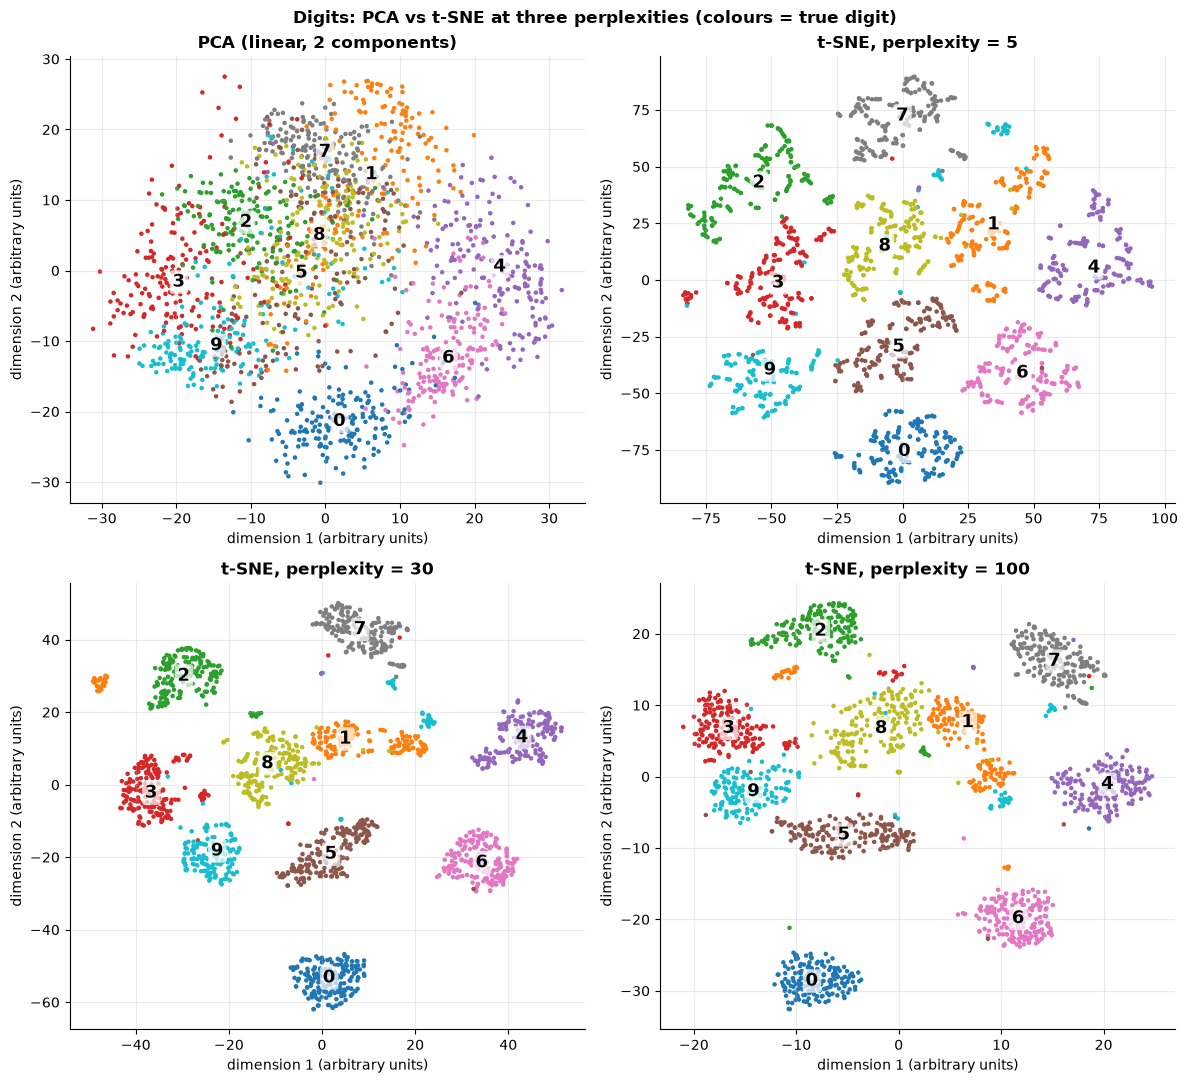

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
panels = [("PCA (linear, 2 components)", Z_dig)] + [(f"t-SNE, perplexity = {p}", Z_tsne[p]) for p in Z_tsne]
for ax, (title, Z2) in zip(axes.ravel(), panels):
    ax.scatter(*Z2.T, c=y_dig, cmap="tab10", s=5)
    for d in range(10):
        ax.text(*np.median(Z2[y_dig == d], axis=0), str(d), fontsize=13, weight="bold", ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, lw=0))
    ax.set(title=title, xlabel="dimension 1 (arbitrary units)", ylabel="dimension 2 (arbitrary units)")
fig.suptitle("Digits: PCA vs t-SNE at three perplexities (colours = true digit)", fontweight="bold")
fig.tight_layout()
savefig("tsne_perplexity")
plt.show()

**How (not) to read a t-SNE plot**

- **Cluster sizes mean nothing.** t-SNE adapts $\sigma_i$ to local density, so dense and sparse clusters come out
  similar in size.
- **Distances between clusters mean little.** That "4" sits next to "0" in one run says almost nothing about
  similarity; global layout depends on perplexity, initialisation and the random seed.
- **It is stochastic and non-parametric.** There is no `transform` for new points; re-running with another seed
  gives a different (rotated/reflected/re-arranged) picture.
- **Perplexity matters.** Low perplexity → many small fragments; high → more global structure, slower.
- **Don't cluster on t-SNE output** and then claim the clusters are real; use it to *look*, then verify.

| | PCA | t-SNE |
|---|---|---|
| Type | linear projection | non-linear embedding |
| Preserves | global variance / large distances | local neighbourhoods |
| New data | `transform()` | refit needed (non-parametric) |
| Deterministic | yes (up to sign) | no (seed-dependent) |
| Speed | fast (one SVD) | slow ($O(n\log n)$ per iteration with Barnes–Hut) |
| Typical use | preprocessing, compression, denoising, quick look | visualisation only |

## 8 · Evaluating clusters against labels (sanity check)

In real unsupervised problems there are no labels — you rely on internal criteria (silhouette, stability, domain
sense). But on benchmark data with known classes, the **Adjusted Rand Index** tells us whether a pipeline finds
the "obvious" structure. ARI counts pairs of points that are grouped together/apart consistently in both
partitions, corrected for chance:

$$\text{ARI} = \frac{\text{RI} - \mathbb E[\text{RI}]}{\max \text{RI} - \mathbb E[\text{RI}]}.$$

Remember: the "true" classes are just one possible grouping; a clustering that disagrees is not necessarily wrong.

In [20]:
rows = []
def add(name, labels, X_for_sil):
    rows.append({"pipeline": name, "ARI vs digit": adjusted_rand_score(y_dig, labels),
                 "silhouette (in its own space)": silhouette_score(X_for_sil, labels)})

add("k-means, raw 64 pixels", KMeans(10, n_init=10, random_state=RANDOM_STATE).fit_predict(X_dig), X_dig)
X_p20 = PCA(20, random_state=RANDOM_STATE).fit_transform(X_dig)
add("k-means on PCA(20)", KMeans(10, n_init=10, random_state=RANDOM_STATE).fit_predict(X_p20), X_p20)
add("Ward agglomerative, raw", AgglomerativeClustering(10, linkage="ward").fit_predict(X_dig), X_dig)
add("GMM (diag) on PCA(20)", GaussianMixture(10, covariance_type="diag", random_state=RANDOM_STATE).fit_predict(X_p20), X_p20)
add("k-means on t-SNE(30) map ⚠", KMeans(10, n_init=10, random_state=RANDOM_STATE).fit_predict(Z_tsne[30]), Z_tsne[30])
res = pd.DataFrame(rows).set_index("pipeline").round(3)
res

,ARI vs digit,silhouette (in its own space)
pipeline,,
"k-means, raw 64 pixels",0.667,0.182
k-means on PCA(20),0.670,0.213
"Ward agglomerative, raw",0.794,0.178
GMM (diag) on PCA(20),0.607,0.202
k-means on t-SNE(30) map ⚠,0.883,0.639


k-means on the t-SNE map scores highest on ARI — tempting, but t-SNE was tuned for *looking*, cannot embed new
points, and its silhouette is inflated by construction. Treat that row as a curiosity, not a method.

In [21]:
print(f"Total notebook runtime: {time.time() - T0:.0f}s")

Total notebook runtime: 41s


## Key takeaways

- **k-means** = Lloyd's alternating assign/update steps minimising inertia; converges to a *local* optimum, so use
  **k-means++** seeding and several restarts (`n_init`).
- Choose $k$ with the **elbow** curve and **silhouette** scores/plots — and domain knowledge. Inertia alone always
  prefers larger $k$.
- k-means assumes round, similarly-sized clusters. **GMMs** handle elliptical clusters of different spread;
  **DBSCAN** handles arbitrary shapes and noise but needs a sensible `eps` on scaled data.
- **Hierarchical clustering** builds a dendrogram; the **linkage** (single/complete/average/ward) controls cluster
  shape. Cut the tree where the merge distances jump.
- **PCA** = SVD of the centred data. Explained variance ratio $= \sigma_j^2/\sum\sigma^2$. Components are defined
  only **up to sign**. **Standardise** features in different units first.
- **t-SNE** is for visualisation: local neighbourhoods are meaningful; cluster sizes, gaps and global layout are not.
- ARI against known labels is a **sanity check**, not a goal.

## Exercises

1. **Bad seeds.** Run the from-scratch `lloyd` from 50 random (non-++) initialisations on the blobs with $k=4$ and
   plot the histogram of final inertias. Repeat with `kmeans_plusplus`. *Hint:* count how often each reaches the
   minimum inertia found.
2. **Mini-batch.** Time `KMeans` vs `MiniBatchKMeans` on `make_blobs(n_samples=200_000)`. How much inertia do you
   lose? *Hint:* compare `inertia_` on the same data and use `time.perf_counter()`.
3. **GMM model selection.** For the unequal-variance data, choose the number of GMM components with BIC.
   *Hint:* `GaussianMixture(...).fit(X).bic(X)` for `n_components` in 1..8; lower is better.
4. **PCA whitening & classification.** Build `Pipeline([StandardScaler(), PCA(k), LogisticRegression()])` on digits
   and plot 5-fold CV accuracy vs $k$. *Hint:* accuracy saturates well before 64 components.
5. **t-SNE stability.** Re-run t-SNE (perplexity 30) with three different `random_state`s and compare the plots. What
   stays the same? *Hint:* look at which digits are neighbours vs where clusters sit on the canvas.